Import libraries needed to assess Louisville data, including geographic data.

In [1]:
import pandas as pd   # for creating dataframes
import geopandas as gpd   # for reading data sets in GeoJSON files
from geopy.distance import geodesic   # for converting shape lengths calculated in degrees to miles
import matplotlib.pyplot as plt   # for plotting visualizations
import matplotlib.patches as mpatches   # for custom visualization labels
from matplotlib import colormaps   # for access to colormaps used in visualizations
from shapely.geometry import Point, LineString, shape   # for geopandas geometry management
import sqlite3   # for reading to and writing from SQLite database files

Read in various geodata files and shapefiles. Ensure their CRS are aligned, and clip the data to within Jefferson County only.

In [2]:
# geometric shapefile to draw Jefferson County
county_shape = gpd.read_file('data/Ky_County_Polygons/Ky_County_Polygons_WM.shp')
county_shape.to_crs(epsg='4326', inplace=True)      # the GeoJSON files provided by data.louisville.gov use CRS EPSG:4326
jefferson_co = county_shape[county_shape['NAME']=='JEFFERSON']

# major roads data for Louisville metro area includes southern Indiana; clip to Jefferson County
major_roads = gpd.read_file('data/Louisville_Metro_Area_KY_Major_Roads.geojson')
major_roads.dropna(inplace=True)    # one row had mostly NaN values
# clip major roads to Jefferson County only
jeffco_roads = gpd.clip(major_roads, jefferson_co)
jeffco_roads.name = 'jeffco_roads'

# high injury roadway network data for Louisville metro area includes southern Indiana; clip to Jefferson County
hi_injury = gpd.read_file('data/Louisville_Metro_KY_-_High_Injury_Network.geojson')
hi_injury.name = 'hi_injury'

# bikeways data
bikeways = gpd.read_file('data/Jefferson_County_KY_Bikeways.geojson')
bikeways.name = 'bikeways'

# TARC bus stop data for Louisville metro area includes southern Indiana; clip to Jefferson County
bus_stops = gpd.read_file('data/Louisville_Metro_Area_KY__TARC_Bus_Stops.geojson')
bus_stops = gpd.clip(bus_stops, jefferson_co)
bus_stops.name = 'bus_stops'

# midblock crossings (crosswalks) data
crosswalks = gpd.read_file('data/Jefferson_County_KY_Midblock_Crossings.geojson')
crosswalks.name = 'crosswalks'

Introductory and exploratory plot demonstrating that all datasets have been reduced to and are contained within Jefferson County, KY

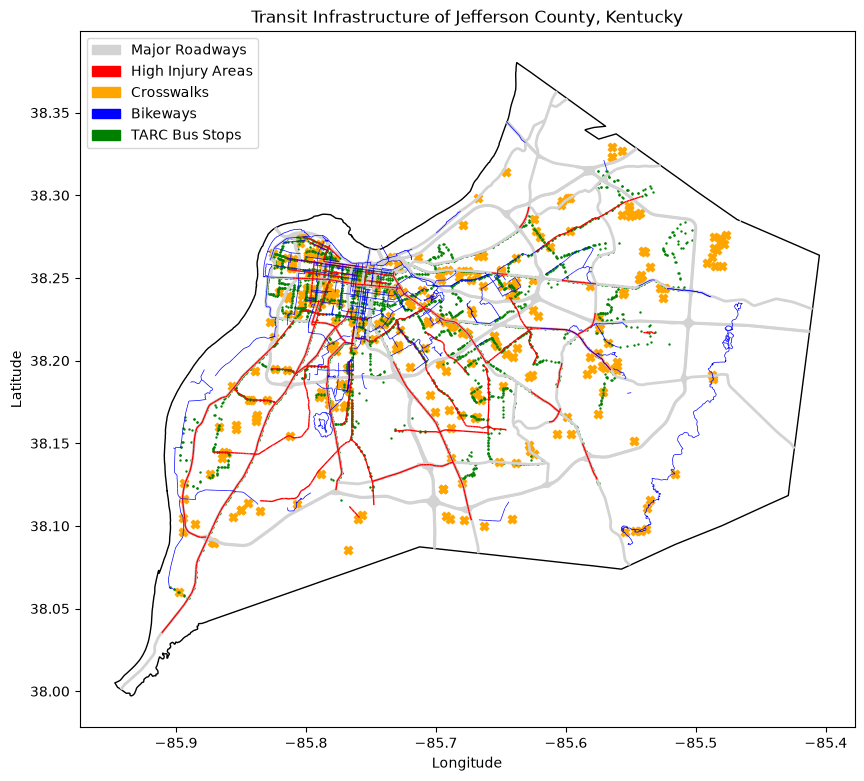

In [3]:
fig, ax = plt.subplots(figsize = (10, 10))

jefferson_co.plot(ax = ax, color='none', edgecolor='black')
jeffco_roads.plot(ax = ax, color='lightgray', linewidth=2) 
hi_injury.plot(ax = ax, color='red', linewidth=1)
crosswalks.plot(ax = ax, color='orange', marker="X")
bikeways.plot(ax = ax, color='blue', linewidth=0.5)
bus_stops.plot(ax = ax, color='green', markersize=0.5)

grey_lines = mpatches.Patch(color='lightgrey', label='Major Roadways')
red_lines = mpatches.Patch(color='red', label='High Injury Areas')
orange_xs = mpatches.Patch(color='orange', label='Crosswalks')
blue_lines = mpatches.Patch(color='blue', label='Bikeways')
green_dots = mpatches.Patch(color='green', label='TARC Bus Stops')

ax.legend(loc='upper left', handles=[grey_lines, red_lines, orange_xs, blue_lines, green_dots])

plt.title("Transit Infrastructure of Jefferson County, Kentucky")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

Collect dataframes in a list for batch processing of multiple dataframes.

In [4]:
data_sets = [hi_injury, bikeways, bus_stops, crosswalks]

Create a function to check dataframes for null values and fill those null value cells with values of the appropriate datatype.

In [5]:
def check_nulls(df):
    df_na = df.columns[df.isna().any()].tolist()
    if not df_na:
        pass   # if there are no missing values, do nothing.
    else:
        for i in df_na:
            if df[i].dtypes == 'str':
                df[i].fillna("None")   # if the missing value is in a string column, replace NaN with string "None"
            elif df[i].dtypes == 'float64':
                df[i].fillna(0)   # if the missing value is in a float column, replace the NaN with 0
            elif df[i].dtypes == 'int32':
                df[i].fillna(0)   # if the missing value is in an int column, replace the NaN with 0
            else:
                pass   # we happen to know that there are not other data types in these dataframes that will need to be filled, but further elif statements could be added here for additional datatypes if needed.

Apply null-checking function to all dataframes being assessed.

In [6]:
for each_set in data_sets:
    check_nulls(each_set)

In [7]:
# * hi_injury
# bikeways
# bus_stops
# * crosswalks

Geodata files by default provide length as measured in degrees. For a human-readable measure of distance, we must define a function that will calculate the cumulative length of the each segment's "linestring." Linestring is just a list of coordinates stored in an array, readable by *pandas*, *python*, and other software, that can be used to draw the segments accurately on map plots.

In [8]:
def calc_length(line_geometry):
    if not isinstance(line_geometry, LineString):
        return None     # essentially, skip the row if there is no linestring provided
    seg_length_mi = 0   # establish baseline segment length (e.g. no length at start)
    coords = list(line_geometry.coords)
    for p in range(len(coords) - 1):
        point1 = (coords[p][1], coords[p][0]) # geopy requires (latitude, longitude)
        point2 = (coords[p+1][1], coords[p+1][0])
        seg_length_mi += geodesic(point1, point2).mi   # add length between points in linestring to total segment length in miles
    return seg_length_mi

Verify every dataframe, all derived from GeoJSON files, contains a *geometry* column. 

In [ ]:
linestring_datasets = []   # linestring datasets will compare lengths of roadway segment against high injury netowork.
point_datasets = []   # point datasets will compare counts of points in high injury network.
item_check = False

for each_set in data_sets:
    column_list = each_set.columns.to_list()
    if 'geometry' not in column_list:
        print(f"Dataframe {each_set} contains no 'geometry' column.")
    else:
        for gi in each_set['geometry']:
            if gi == 'LineString':
                item_check = True
                linestring_datasets += each_set.name
            elif each_set['geometry'].geom_type.all() == 'Point':
                point_datasets += each_set.name
            else:
                print('Uh oh! This program cannot handle the geometry type of this dataset.')

bikeways['geometry'].geom_type


Uh oh! This program cannot handle the geometry type of this dataset.
Uh oh! This program cannot handle the geometry type of this dataset.
Uh oh! This program cannot handle the geometry type of this dataset.
Uh oh! This program cannot handle the geometry type of this dataset.


0       LineString
1       LineString
2       LineString
3       LineString
4       LineString
           ...    
1717    LineString
1718    LineString
1719    LineString
1720    LineString
1721    LineString
Length: 1722, dtype: str

# Two dataframes have *linestring* geometries. Two have *point* geometries. 
Write a function to determine which dataframes have which geom_type, and write the df.name to identifying lists. 
Or... this overcomplicates in a stretch to meet the rubric: 3rd function. Maybe instead a function to write select columns to the SQL db file?

# **NOTE TO SELF:** The above function is built but not yet tested as of 6-Aug-2026. 
- You still need to apply this function to the geometry / linestring columns of your dataframes. 
- Generate a new column in each dataframe called (something like) "Segment Length (miles)"